# D_S1.1 — Parameter-Diverse Dataset for Sequential Fuzzy Calibration

This notebook builds the new experimental design without changing the existing `output/S1` dataset.

Core design:

- 26 signal families plus a separately parameterized Null family.
- 5 target-feature strength levels per family.
- 8 nuisance-parameter groups per family, selected from a larger candidate pool.
- 40 base functions per family.
- 50 log-spaced SNR levels from `100` to `0.01`, plus a noise-free baseline.
- Grouped development/test split and grouped cross-validation.
- Visual labels are assigned per **base function and SNR**, not fixed by family.
- A later Gate receives a case only when the preceding fuzzy membership is `>= alpha`.

Important: a strong special feature and a Global relationship are separate labels. For example, a fast front-loaded Saturation can have `saturation = 1` and `global = 0`.

In [1]:
from __future__ import annotations

import json
import math
import os
import time
from dataclasses import asdict, dataclass
from itertools import combinations
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, rankdata, spearmanr

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# Safe default is design-only. Set PARAM_FUZZY_MODE=pilot or full when executing.
MODE = os.environ.get('PARAM_FUZZY_MODE', 'design').strip().lower()
if MODE not in {'design', 'pilot', 'full'}:
    raise ValueError(f'Unknown PARAM_FUZZY_MODE={MODE!r}')
REUSE_EXISTING = os.environ.get('PARAM_FUZZY_REUSE', '0').strip() == '1'
WRITE_DESIGN_TABLES = MODE in {'pilot', 'full'}
WRITE_CASE_TABLE = MODE in {'pilot', 'full'}
WRITE_SCATTER_POINTS = MODE in {'pilot', 'full'} and not REUSE_EXISTING
RUN_FUZZY_CALIBRATION = MODE == 'full'

OUTPUT_ROOT = Path('output/S1_parameterized')
OUTPUT_DIR = OUTPUT_ROOT / 'pilot' if MODE == 'pilot' else OUTPUT_ROOT
METRICS_ROOT = Path('output/S2_parameterized')
METRICS_PATH = (METRICS_ROOT / 'pilot_metrics.parquet'
                if MODE == 'pilot' else METRICS_ROOT / 'metrics_full.parquet')
LABELS_PATH = OUTPUT_DIR / 'case_visual_labels.csv'

RANDOM_SEED = 20260717
N_PER_CASE = 500
N_REPLICATES = 3
ALPHA = 0.5
ALPHA_CANDIDATES = np.round(np.arange(0.35, 0.66, 0.05), 2)
N_JOBS_MIC = min(8, os.cpu_count() or 1)

STRENGTH_NAMES = ['very_weak', 'weak', 'medium', 'strong', 'very_strong']
SNR_GRID_FULL = np.geomspace(0.01, 100.0, 50).tolist() + [math.inf]
SNR_GRID_PILOT = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, math.inf]
PILOT_FAMILIES = ['F01', 'F03', 'F07', 'F13', 'F19', 'F23', 'F26', 'Null']

print(f'Mode: {MODE}')
print(f'Full design: 26 families x 5 strengths x 8 nuisance groups = {26 * 5 * 8:,} base functions')
print(f'Full signal cases before adaptive boundary replicates: {26 * 5 * 8 * len(SNR_GRID_FULL) * N_REPLICATES:,}')
print(f'Null cases: {8 * len(SNR_GRID_FULL) * N_REPLICATES:,}')

Mode: full
Full design: 26 families x 5 strengths x 8 nuisance groups = 1,040 base functions
Full signal cases before adaptive boundary replicates: 159,120
Null cases: 1,224


## 1. Family catalogue and paired directions

Positive/negative counterparts share the same nuisance groups and split assignment. This prevents direction from being confounded with parameter choice.

In [2]:
FAMILY_NAMES = {
    'F01': 'Linear positive', 'F02': 'Linear negative',
    'F03': 'Power convex positive', 'F04': 'Power convex negative',
    'F05': 'Power concave positive', 'F06': 'Power concave negative',
    'F07': 'Saturation positive', 'F08': 'Saturation negative',
    'F09': 'Log positive', 'F10': 'Log negative',
    'F11': 'Exponential positive', 'F12': 'Exponential negative',
    'F13': 'S-curve positive', 'F14': 'S-curve negative',
    'F15': 'Threshold positive', 'F16': 'Threshold negative',
    'F17': 'Quadratic peak', 'F18': 'Quadratic valley',
    'F19': 'Spike', 'F20': 'Inverted spike',
    'F21': 'Cubic', 'F22': 'Complex non-monotonic',
    'F23': 'Two lines', 'F24': 'Line and parabola',
    'F25': 'Multi-regime threshold', 'F26': 'Windowed threshold',
    'Null': 'No relationship',
}

PAIR_CANONICAL = {
    'F02': 'F01', 'F04': 'F03', 'F06': 'F05', 'F08': 'F07',
    'F10': 'F09', 'F12': 'F11', 'F14': 'F13', 'F16': 'F15',
    'F18': 'F17', 'F20': 'F19',
}
CANONICAL_FAMILIES = [fid for fid in FAMILY_NAMES if fid != 'Null' and fid not in PAIR_CANONICAL]
SIGNAL_FAMILIES = [f'F{i:02d}' for i in range(1, 27)]
MULTI_BRANCH_FAMILIES = {'F23', 'F24', 'F25'}

family_catalogue = pd.DataFrame({
    'family_id': SIGNAL_FAMILIES,
    'family_name': [FAMILY_NAMES[fid] for fid in SIGNAL_FAMILIES],
    'canonical_family': [PAIR_CANONICAL.get(fid, fid) for fid in SIGNAL_FAMILIES],
})
display(family_catalogue)

,family_id,family_name,canonical_family
0,F01,Linear positive,F01
1,F02,Linear negative,F01
2,F03,Power convex positive,F03
3,F04,Power convex negative,F03
4,F05,Power concave positive,F05
5,F06,Power concave negative,F05
6,F07,Saturation positive,F07
7,F08,Saturation negative,F07
8,F09,Log positive,F09
9,F10,Log negative,F09


## 2. Parameterized signal functions

Each family has a primary strength axis plus three continuous nuisance coordinates `u1/u2/u3`. The coordinates are mapped to family-specific parameters. The eight retained nuisance groups are selected from 48 Latin-hypercube candidates by maximin distance over parameters and clean curve signatures.

For one-parameter invariant families such as exact lines, nuisance parameters mainly test robustness; they are not interpreted as different degrees of linearity.

In [3]:
def lerp(lo: float, hi: float, u: float) -> float:
    return float(lo + (hi - lo) * u)


def build_params(fid: str, strength_index: int, u: np.ndarray) -> dict[str, Any]:
    canonical = PAIR_CANONICAL.get(fid, fid)
    u1, u2, u3 = map(float, u)

    if canonical == 'F01':
        slopes = [0.25, 0.5, 1.0, 2.0, 4.0]
        return {'slope': slopes[strength_index], 'intercept': lerp(-0.5, 0.5, u1),
                'x_offset': lerp(0.0, 0.15, u2), 'x_scale': lerp(0.8, 1.2, u3)}
    if canonical == 'F03':
        powers = [1.08, 1.25, 1.7, 2.6, 4.0]
        return {'p': powers[strength_index], 'h': lerp(0.0, 0.25, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F05':
        powers = [0.92, 0.78, 0.58, 0.32, 0.12]
        return {'p': powers[strength_index], 'h': lerp(0.0, 0.18, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F07':
        rates = [0.5, 1.2, 2.5, 6.0, 15.0]
        return {'k': rates[strength_index], 'onset': lerp(0.0, 0.18, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F09':
        scales = [0.5, 1.5, 5.0, 20.0, 80.0]
        return {'a': scales[strength_index], 'h': lerp(0.0, 0.2, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F11':
        rates = [0.2, 0.5, 1.0, 2.0, 4.0]
        return {'rate': rates[strength_index], 'x_offset': lerp(0.0, 0.12, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F13':
        steepness = [1.5, 3.0, 6.0, 10.0, 16.0]
        return {'k': steepness[strength_index], 'c': lerp(0.3, 0.7, u1),
                'nu': lerp(0.7, 1.3, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F15':
        widths = [0.35, 0.22, 0.12, 0.06, 0.02]
        return {'delta': widths[strength_index], 'c': lerp(0.3, 0.7, u1),
                'gap': lerp(0.7, 1.3, u2), 'baseline': lerp(-0.2, 0.2, u3)}
    if canonical == 'F17':
        curvature = [0.15, 0.45, 1.2, 3.5, 10.0]
        return {'a': curvature[strength_index], 'c': lerp(0.3, 0.7, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'linear_slope': lerp(0.8, 1.2, u3)}
    if canonical == 'F19':
        widths = [0.30, 0.22, 0.14, 0.08, 0.04]
        return {'width': widths[strength_index], 'c': lerp(0.25, 0.75, u1),
                'amplitude': lerp(0.8, 1.2, u2), 'baseline': lerp(-0.2, 0.2, u3)}
    if canonical == 'F21':
        amplitudes = [0.2, 0.6, 1.8, 5.0, 12.0]
        return {'a': amplitudes[strength_index], 'center': lerp(0.42, 0.58, u1),
                'spacing': lerp(0.12, 0.26, u2), 'orientation': -1.0 if u3 < 0.5 else 1.0}
    if canonical == 'F22':
        cycles = [0.5, 1.0, 2.0, 3.0, 5.0]
        subtype_names = ['pure', 'phase', 'damped', 'growing', 'trend_up', 'trend_down',
                         'varying_frequency', 'double_gaussian']
        subtype = subtype_names[min(int(u1 * len(subtype_names)), len(subtype_names) - 1)]
        return {'cycles': cycles[strength_index], 'subtype': subtype,
                'phase': lerp(0.0, math.pi / 2, u2), 'secondary': lerp(0.3, 1.2, u3)}
    if canonical == 'F23':
        separation = [0.2, 0.5, 1.0, 1.8, 3.0]
        return {'separation': separation[strength_index], 'base_slope': lerp(0.2, 1.0, u1),
                'intercept_gap': lerp(0.0, 0.5, u2), 'mix_prob': lerp(0.3, 0.7, u3)}
    if canonical == 'F24':
        curvature = [0.3, 0.7, 1.2, 2.0, 3.5]
        return {'a_para': curvature[strength_index], 'm': lerp(0.8, 3.0, u1),
                'h': lerp(0.3, 0.7, u2), 'mix_prob': lerp(0.3, 0.7, u3), 'peak': 0.5}
    if canonical == 'F25':
        steepness = [2.0, 4.0, 6.0, 9.0, 13.0]
        return {'steepness': steepness[strength_index], 'shift': lerp(-0.04, 0.04, u1),
                'overlap': lerp(0.04, 0.16, u2), 'height_scale': lerp(0.8, 1.2, u3)}
    if canonical == 'F26':
        steepness = [2.0, 4.0, 6.0, 9.0, 13.0]
        return {'steepness': steepness[strength_index], 'shift': lerp(-0.03, 0.03, u1),
                'width_scale': lerp(0.75, 1.25, u2), 'height_scale': lerp(0.8, 1.2, u3)}
    raise ValueError(f'No parameter builder for {fid}')


def _triangular_local(x: np.ndarray, center: float, width: float) -> np.ndarray:
    return np.maximum(0.0, 1.0 - np.abs(x - center) / max(width, 1e-6))


def evaluate_signal(x: np.ndarray, fid: str, params: dict[str, Any],
                    rng: np.random.Generator | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    canonical = PAIR_CANONICAL.get(fid, fid)
    sign = -1.0 if fid in {'F02', 'F04', 'F06', 'F08', 'F10', 'F12', 'F14', 'F16'} else 1.0
    p = params

    if canonical == 'F01':
        xe = p['x_offset'] + p['x_scale'] * x
        return sign * (p['slope'] * xe + p['intercept'])
    if canonical in {'F03', 'F05'}:
        xe = np.maximum(p['x_scale'] * x + p['h'], 1e-8)
        y = p['amplitude'] * (xe ** p['p'] - p['h'] ** p['p'])
        return sign * y
    if canonical == 'F07':
        z = np.maximum(p['x_scale'] * x - p['onset'], 0.0)
        return sign * p['amplitude'] * (1.0 - np.exp(-p['k'] * z))
    if canonical == 'F09':
        xe = np.maximum(p['x_scale'] * x + p['h'], 0.0)
        y = p['amplitude'] * (np.log1p(p['a'] * xe) - np.log1p(p['a'] * p['h']))
        return sign * y
    if canonical == 'F11':
        xe = p['x_offset'] + p['x_scale'] * x
        y = p['amplitude'] * (np.exp(p['rate'] * xe) - np.exp(p['rate'] * p['x_offset']))
        return sign * y
    if canonical == 'F13':
        logistic = (1.0 + np.exp(-p['k'] * (x - p['c']))) ** (-p['nu'])
        return sign * p['amplitude'] * logistic
    if canonical == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return sign * (p['baseline'] + p['gap'] * t)
    if canonical == 'F17':
        xe = p['x_scale'] * x
        trend = p['linear_slope'] * xe
        bend = p['a'] * (xe - p['c']) ** 2
        return trend - bend if fid == 'F17' else trend + bend
    if canonical == 'F19':
        spike = p['amplitude'] * _triangular_local(x, p['c'], p['width'])
        return p['baseline'] + spike if fid == 'F19' else p['baseline'] + p['amplitude'] - spike
    if canonical == 'F21':
        r1 = p['center'] - p['spacing']
        r2 = p['center']
        r3 = p['center'] + p['spacing']
        cubic = p['a'] * (x - r1) * (x - r2) * (x - r3)
        return p['orientation'] * (x + cubic)
    if canonical == 'F22':
        omega = 2.0 * math.pi * p['cycles']
        phase = p['phase']
        subtype = p['subtype']
        if subtype == 'pure':
            return np.sin(omega * x)
        if subtype == 'phase':
            return np.sin(omega * x + phase)
        if subtype == 'damped':
            return np.exp(-p['secondary'] * x) * np.sin(omega * x + phase)
        if subtype == 'growing':
            return np.exp(0.5 * p['secondary'] * x) * np.sin(omega * x + phase)
        if subtype == 'trend_up':
            return p['secondary'] * x + np.sin(omega * x + phase)
        if subtype == 'trend_down':
            return -p['secondary'] * x + np.sin(omega * x + phase)
        if subtype == 'varying_frequency':
            return np.sin(omega * x * (1.0 + p['secondary'] * x) + phase)
        sep = lerp(0.12, 0.32, min(p['cycles'] / 5.0, 1.0))
        sigma = lerp(0.18, 0.06, min(p['cycles'] / 5.0, 1.0))
        return (np.exp(-((x - (0.5 - sep)) / sigma) ** 2)
                + p['secondary'] * np.exp(-((x - (0.5 + sep)) / sigma) ** 2))
    if canonical == 'F23':
        y0 = p['base_slope'] * x
        y1 = (p['base_slope'] + p['separation']) * x + p['intercept_gap']
        if rng is None:
            return p['mix_prob'] * y0 + (1.0 - p['mix_prob']) * y1
        choose_first = rng.random(len(x)) < p['mix_prob']
        return np.where(choose_first, y0, y1)
    if canonical == 'F24':
        y_line = p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return p['mix_prob'] * y_line + (1.0 - p['mix_prob']) * y_para
        choose_line = rng.random(len(x)) < p['mix_prob']
        return np.where(choose_line, y_line, y_para)
    if canonical == 'F25':
        starts = np.array([0.00, 0.22, 0.43, 0.65]) + p['shift']
        widths = np.array([0.34, 0.34, 0.34, 0.35]) + p['overlap']
        heights = p['height_scale'] * np.array([1.0, 1.4, 0.8, 1.2])
        branch_vals = np.full((4, len(x)), np.nan)
        for k, (start, width, height) in enumerate(zip(starts, widths, heights)):
            end = min(start + width, 1.0)
            mask = (x >= max(start, 0.0)) & (x <= end)
            if mask.any():
                z = (x[mask] - max(start, 0.0)) / max(end - max(start, 0.0), 1e-6)
                branch_vals[k, mask] = height * np.expm1(p['steepness'] * z) / np.expm1(p['steepness'])
        if rng is None:
            count = np.sum(np.isfinite(branch_vals), axis=0)
            total = np.nansum(branch_vals, axis=0)
            return np.divide(total, count, out=np.zeros_like(total), where=count > 0)
        priorities = rng.random(branch_vals.shape)
        priorities[np.isnan(branch_vals)] = -1.0
        selected = np.argmax(priorities, axis=0)
        y = branch_vals[selected, np.arange(len(x))]
        return np.where(np.isnan(y), 0.0, y)
    if canonical == 'F26':
        centers = np.array([0.12, 0.36, 0.60, 0.84]) + p['shift']
        widths = p['width_scale'] * np.array([0.12, 0.14, 0.12, 0.10])
        heights = p['height_scale'] * np.array([1.0, 1.6, 0.7, 1.3])
        y = np.zeros_like(x)
        for center, width, height in zip(centers, widths, heights):
            left, right = center - width / 2.0, center + width / 2.0
            mask = (x >= left) & (x <= right)
            if mask.any():
                z = (x[mask] - left) / max(width, 1e-6)
                y[mask] = height * np.expm1(p['steepness'] * z) / np.expm1(p['steepness'])
        return y
    if fid == 'Null':
        return np.zeros_like(x)
    raise ValueError(f'Unknown family: {fid}')

## 3. Select eight diverse nuisance groups

Selection is performed before noisy data and metrics exist. No MIC, fuzzy membership, classification accuracy, or noisy visual label is used.

In [4]:
def latin_hypercube(n: int, d: int, rng: np.random.Generator) -> np.ndarray:
    result = np.empty((n, d), dtype=float)
    for j in range(d):
        result[:, j] = (rng.permutation(n) + rng.random(n)) / n
    return result


def normalized_curve_signature(fid: str, u: np.ndarray, grid_size: int = 240) -> np.ndarray:
    x = np.linspace(0.0, 1.0, grid_size)
    signatures = []
    for strength_index in range(5):
        params = build_params(fid, strength_index, u)
        y = evaluate_signal(x, fid, params)
        y = np.asarray(y, dtype=float)
        y = (y - np.nanmean(y)) / max(float(np.nanstd(y)), 1e-10)
        signatures.append(y)
    return np.concatenate(signatures)


def select_maximin_groups(fid: str, n_candidates: int = 48, n_select: int = 8) -> pd.DataFrame:
    seed = RANDOM_SEED + int(fid[1:]) * 101
    rng = np.random.default_rng(seed)
    candidates = latin_hypercube(n_candidates, 3, rng)
    signatures = np.vstack([normalized_curve_signature(fid, u) for u in candidates])
    signatures = signatures / np.sqrt(signatures.shape[1])
    features = np.column_stack([2.0 * candidates, signatures])
    distances = np.sqrt(np.maximum(
        ((features[:, None, :] - features[None, :, :]) ** 2).sum(axis=2), 0.0
    ))

    first_pair = np.unravel_index(np.argmax(distances), distances.shape)
    selected = [int(first_pair[0]), int(first_pair[1])]
    while len(selected) < n_select:
        min_distance = distances[:, selected].min(axis=1)
        min_distance[selected] = -np.inf
        selected.append(int(np.argmax(min_distance)))

    chosen = candidates[selected]
    order = np.lexsort((chosen[:, 2], chosen[:, 1], chosen[:, 0]))
    chosen = chosen[order]
    return pd.DataFrame({
        'canonical_family': fid,
        'nuisance_group': [f'G{i+1:02d}' for i in range(n_select)],
        'u1': chosen[:, 0], 'u2': chosen[:, 1], 'u3': chosen[:, 2],
    })


parameter_groups = pd.concat(
    [select_maximin_groups(fid) for fid in CANONICAL_FAMILIES],
    ignore_index=True,
)

# Null uses eight independent marginal/noise profiles. Its parameters are
# selected before metrics in the same way, but it has no strength axis.
null_rng = np.random.default_rng(RANDOM_SEED + 909)
null_u = latin_hypercube(8, 3, null_rng)
null_groups = pd.DataFrame({
    'canonical_family': 'Null',
    'nuisance_group': [f'G{i+1:02d}' for i in range(8)],
    'u1': null_u[:, 0], 'u2': null_u[:, 1], 'u3': null_u[:, 2],
})
parameter_groups = pd.concat([parameter_groups, null_groups], ignore_index=True)

assert parameter_groups.groupby('canonical_family').size().eq(8).all()
print(f'Canonical family designs (including Null): {parameter_groups["canonical_family"].nunique()}')
print(f'Selected nuisance groups: {len(parameter_groups)}')
display(parameter_groups.head(16).round(3))

Canonical family designs (including Null): 17
Selected nuisance groups: 136


,canonical_family,nuisance_group,u1,u2,u3
0,F01,G01,0.035,0.070,0.800
1,F01,G02,0.103,0.580,0.119
2,F01,G03,0.450,0.426,0.521
3,F01,G04,0.563,0.089,0.000
4,F01,G05,0.594,0.773,0.982
5,F01,G06,0.845,0.990,0.071
6,F01,G07,0.875,0.178,0.908
7,F01,G08,0.996,0.043,0.351
8,F03,G01,0.002,0.635,0.752
9,F03,G02,0.038,0.558,0.005


## 4. Build the 1,048 base functions

Global/No Global is deliberately **not** assigned from `family_id`. The clean curve receives an active-change proxy, but final `0/0.5/1` labels must be filled from the review plots.

In [5]:
@dataclass(frozen=True)
class BaseFunction:
    base_function_id: int
    family_id: str
    family_name: str
    canonical_family: str
    nuisance_group: str
    strength_index: int
    strength_name: str
    params: dict[str, Any]


group_lookup = {
    (row.canonical_family, row.nuisance_group): np.array([row.u1, row.u2, row.u3])
    for row in parameter_groups.itertuples(index=False)
}

base_functions = []
for fid in SIGNAL_FAMILIES:
    canonical = PAIR_CANONICAL.get(fid, fid)
    groups = parameter_groups[parameter_groups['canonical_family'].eq(canonical)]
    for group in groups.itertuples(index=False):
        u = np.array([group.u1, group.u2, group.u3])
        for strength_index, strength_name in enumerate(STRENGTH_NAMES):
            base_functions.append(BaseFunction(
                base_function_id=len(base_functions) + 1,
                family_id=fid,
                family_name=FAMILY_NAMES[fid],
                canonical_family=canonical,
                nuisance_group=group.nuisance_group,
                strength_index=strength_index,
                strength_name=strength_name,
                params=build_params(fid, strength_index, u),
            ))

null_x_distributions = ['even', 'left_dense', 'right_dense', 'center_dense']
null_noise_distributions = ['normal', 'student_t5', 'uniform']
for group in null_groups.itertuples(index=False):
    params = {
        'x_distribution': null_x_distributions[min(int(group.u1 * 4), 3)],
        'noise_distribution': null_noise_distributions[min(int(group.u2 * 3), 2)],
        'marginal_scale': lerp(0.8, 1.2, group.u3),
    }
    base_functions.append(BaseFunction(
        base_function_id=len(base_functions) + 1,
        family_id='Null',
        family_name=FAMILY_NAMES['Null'],
        canonical_family='Null',
        nuisance_group=group.nuisance_group,
        strength_index=-1,
        strength_name='not_applicable',
        params=params,
    ))


def clean_descriptors(cfg: BaseFunction, grid_size: int = 1001) -> dict[str, float]:
    x = np.linspace(0.0, 1.0, grid_size)
    y = evaluate_signal(x, cfg.family_id, cfg.params)
    dy = np.gradient(y, x)
    ddy = np.gradient(dy, x)
    max_slope = float(np.nanmax(np.abs(dy)))
    active = np.abs(dy) >= 0.1 * max(max_slope, 1e-12)
    active_change_fraction = float(active.mean())
    derivative_sign = np.sign(dy[np.abs(dy) > 0.02 * max(max_slope, 1e-12)])
    monotonic_fraction = float(max(
        np.mean(derivative_sign >= 0) if len(derivative_sign) else 0.0,
        np.mean(derivative_sign <= 0) if len(derivative_sign) else 0.0,
    ))
    curvature_strength = float(np.nanmean(np.abs(ddy)) / max(np.nanstd(y), 1e-12))
    total_variation = float(np.sum(np.abs(np.diff(y))))
    if total_variation > 1e-12:
        cumulative = np.r_[0.0, np.cumsum(np.abs(np.diff(y)))] / total_variation
        x05 = float(np.interp(0.05, cumulative, x))
        x95 = float(np.interp(0.95, cumulative, x))
        change_span_90 = x95 - x05
    else:
        change_span_90 = 0.0
    coeff = np.polyfit(x, y, 1)
    fitted = np.polyval(coeff, x)
    ss_total = float(np.sum((y - y.mean()) ** 2))
    clean_line_r2 = 1.0 - float(np.sum((y - fitted) ** 2)) / ss_total if ss_total > 1e-12 else 0.0
    x90 = np.nan
    if cfg.canonical_family == 'F07':
        k = cfg.params['k'] * cfg.params['x_scale']
        x90 = float(cfg.params['onset'] / cfg.params['x_scale'] + math.log(10.0) / max(k, 1e-12))
    return {
        'active_change_fraction': active_change_fraction,
        'monotonic_fraction': monotonic_fraction,
        'curvature_strength': curvature_strength,
        'change_span_90': change_span_90,
        'clean_line_r2': clean_line_r2,
        'saturation_x90': x90,
    }


base_rows = []
for cfg in base_functions:
    base_rows.append({
        **{k: v for k, v in asdict(cfg).items() if k != 'params'},
        'params_json': json.dumps(cfg.params, sort_keys=True),
        **clean_descriptors(cfg),
    })
base_df = pd.DataFrame(base_rows)

assert len(base_df) == 26 * 5 * 8 + 8
assert base_df[base_df['family_id'].ne('Null')].groupby('family_id').size().eq(40).all()
assert len(base_df[base_df['family_id'].eq('Null')]) == 8
print(f'Base functions: {len(base_df):,}')
display(base_df.groupby(['family_id', 'strength_name']).size().unstack())
display(base_df[base_df['family_id'].isin(['F07', 'F08'])][
    ['base_function_id', 'family_id', 'nuisance_group', 'strength_name',
     'active_change_fraction', 'saturation_x90', 'params_json']
].head(16))

Base functions: 1,048


strength_name,medium,not_applicable,strong,very_strong,very_weak,weak
family_id,,,,,,
F01,8.0,NaN,8.0,8.0,8.0,8.0
F02,8.0,NaN,8.0,8.0,8.0,8.0
F03,8.0,NaN,8.0,8.0,8.0,8.0
F04,8.0,NaN,8.0,8.0,8.0,8.0
F05,8.0,NaN,8.0,8.0,8.0,8.0
F06,8.0,NaN,8.0,8.0,8.0,8.0
F07,8.0,NaN,8.0,8.0,8.0,8.0
F08,8.0,NaN,8.0,8.0,8.0,8.0
F09,8.0,NaN,8.0,8.0,8.0,8.0


,base_function_id,family_id,nuisance_group,strength_name,active_change_fraction,saturation_x90,params_json
240,241,F07,G01,very_weak,0.999001,4.160346,"{""amplitude"": 0.9124166794277202, ""k"": 0.5, ""o..."
241,242,F07,G01,weak,0.999001,1.734115,"{""amplitude"": 0.9124166794277202, ""k"": 1.2, ""o..."
242,243,F07,G01,medium,0.833167,0.832943,"{""amplitude"": 0.9124166794277202, ""k"": 2.5, ""o..."
243,244,F07,G01,strong,0.348651,0.347697,"{""amplitude"": 0.9124166794277202, ""k"": 6.0, ""o..."
244,245,F07,G01,very_strong,0.140859,0.139735,"{""amplitude"": 0.9124166794277202, ""k"": 15.0, ""..."
245,246,F07,G02,very_weak,0.995005,4.037613,"{""amplitude"": 1.1697283770705929, ""k"": 0.5, ""o..."
246,247,F07,G02,weak,0.995005,1.685647,"{""amplitude"": 1.1697283770705929, ""k"": 1.2, ""o..."
247,248,F07,G02,medium,0.808192,0.812060,"{""amplitude"": 1.1697283770705929, ""k"": 2.5, ""o..."
248,249,F07,G02,strong,0.337662,0.341667,"{""amplitude"": 1.1697283770705929, ""k"": 6.0, ""o..."
249,250,F07,G02,very_strong,0.136863,0.140070,"{""amplitude"": 1.1697283770705929, ""k"": 15.0, ""..."


## 5. Clean visual review and annotation templates

Review semantics:

- `1`: the target characteristic is clearly visible.
- `0.5`: the plot does not support a reliable decision.
- `0`: the target characteristic is clearly absent or the Gate-1 Global relationship is not visible.
- `N/A`: the characteristic is outside the Gate's valid analysis scope.

The review view hides metric values. Family and parameter metadata can also be hidden for a blind pass.

Clean labels completed: 1,048
Gate/SNR boundaries completed: 4,192

Global clean-label distribution:


,cases
global_clean_label,
0.0,184
0.5,32
1.0,832



Simple clean-label distribution:


,cases
simple_clean_label,
0.0,325
0.5,198
1.0,525



Monotonic clean-label distribution:


,cases
monotonic_clean_label,
0.0,373
0.5,37
1.0,638



Linear clean-label distribution:


,cases
linear_clean_label,
0.0,654
0.5,156
1.0,238


Saved canonical clean-review sheets to output/S1_parameterized/review_clean


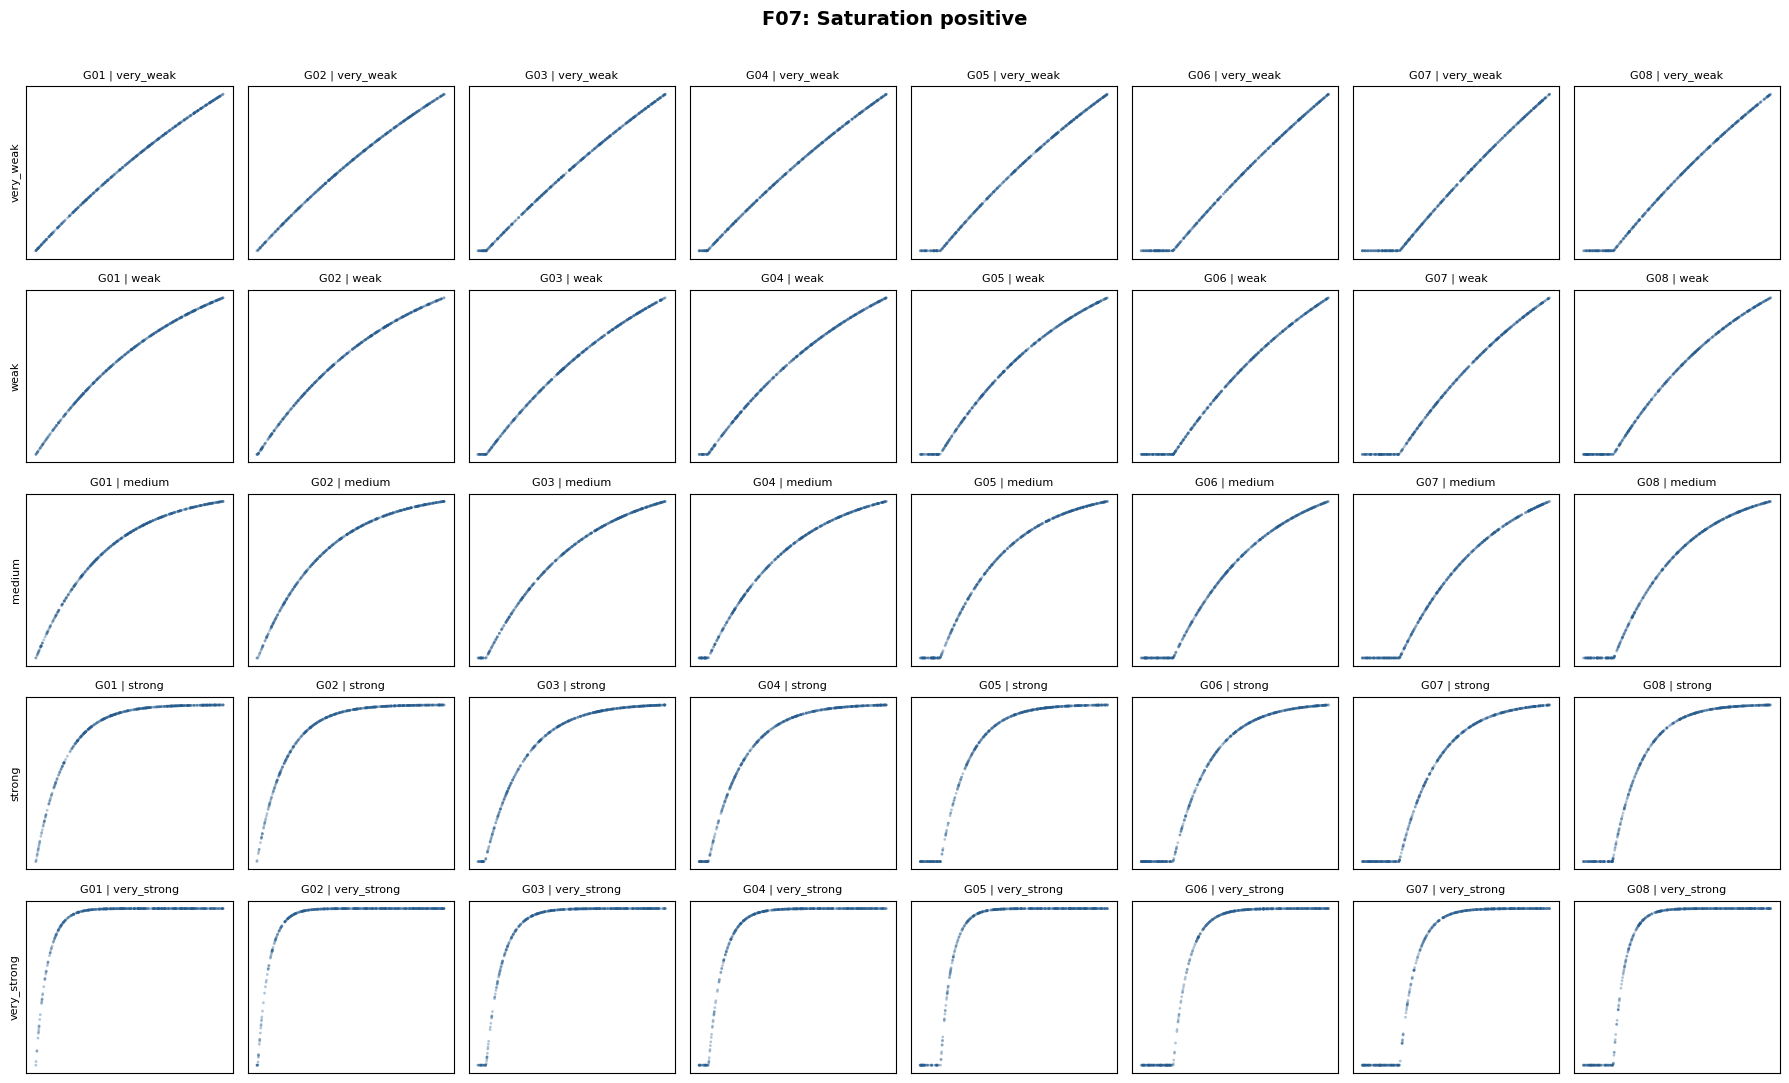

In [6]:
BASE_LOOKUP = {cfg.base_function_id: cfg for cfg in base_functions}


def plot_clean_family(family_id: str, groups: list[str] | None = None,
                      blind: bool = False, figsize=(18, 11)):
    selected = base_df[base_df['family_id'].eq(family_id)].copy()
    if groups is not None:
        selected = selected[selected['nuisance_group'].isin(groups)]
    groups_here = sorted(selected['nuisance_group'].unique())
    strengths_here = STRENGTH_NAMES if family_id != 'Null' else ['not_applicable']
    height = max(2.4, figsize[1] * len(strengths_here) / len(STRENGTH_NAMES))
    fig, axes = plt.subplots(
        len(strengths_here), len(groups_here),
        figsize=(figsize[0], height), squeeze=False,
    )
    x = np.linspace(0.0, 1.0, 500)
    for row_idx, strength_name in enumerate(strengths_here):
        for col_idx, group in enumerate(groups_here):
            ax = axes[row_idx, col_idx]
            match = selected[
                selected['strength_name'].eq(strength_name)
                & selected['nuisance_group'].eq(group)
            ].iloc[0]
            cfg = BASE_LOOKUP[int(match['base_function_id'])]
            rng = np.random.default_rng(RANDOM_SEED + cfg.base_function_id)
            xr = rng.uniform(0.0, 1.0, N_PER_CASE)
            branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
            yr = evaluate_signal(xr, cfg.family_id, cfg.params, branch_rng)
            ax.scatter(xr, yr, s=4, alpha=0.35, color='#245a8d', edgecolors='none')
            title = f'P{cfg.base_function_id:04d}' if blind else f'{group} | {strength_name}'
            ax.set_title(title, fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            if col_idx == 0:
                ax.set_ylabel(strength_name, fontsize=8)
    heading = 'Blind clean review' if blind else f'{family_id}: {FAMILY_NAMES[family_id]}'
    fig.suptitle(heading, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


def clean_visual_codebook(row: pd.Series) -> dict[str, Any]:
    """Encode the clean-plot review; no noisy metric is used here."""
    fid = row['family_id']
    if fid == 'Null':
        return {'global': 0.0, 'simple': 0.0, 'monotonic': 0.0, 'linear': 0.0,
                'notes': 'Independent x and y; all relationship characteristics absent.'}

    # Global means that the relation is supported over a substantial analysis
    # range. Local spikes and segmented/windowed regimes remain No even when MIC
    # is high. For one-sided smooth curves, concentration of 90% of clean change
    # controls the parameter-specific Yes/Uncertain/No judgement.
    if fid in {'F19', 'F20', 'F25', 'F26'}:
        global_label = 0.0
    elif fid in {f'F{i:02d}' for i in range(3, 13)}:
        span = float(row['change_span_90'])
        global_label = 1.0 if span >= 0.60 else (0.5 if span >= 0.35 else 0.0)
    else:
        global_label = 1.0

    if fid in {f'F{i:02d}' for i in range(1, 13)}:
        simple_label = 1.0
    elif fid in {'F13', 'F14', 'F15', 'F16'}:
        simple_label = 0.5
    elif fid in {'F17', 'F18', 'F21'}:
        if row['clean_line_r2'] >= 0.985 and row['monotonic_fraction'] >= 0.99:
            simple_label = 1.0
        elif row['clean_line_r2'] >= 0.93 or row['monotonic_fraction'] >= 0.90:
            simple_label = 0.5
        else:
            simple_label = 0.0
    else:
        simple_label = 0.0

    if fid in {f'F{i:02d}' for i in range(1, 15)}:
        monotonic_label = 1.0
    elif fid in {'F15', 'F16'}:
        monotonic_label = 0.5 if row['strength_index'] <= 1 else 0.0
    elif fid in {'F17', 'F18', 'F21'}:
        fraction = float(row['monotonic_fraction'])
        monotonic_label = 1.0 if fraction >= 0.995 else (0.5 if fraction >= 0.90 else 0.0)
    else:
        monotonic_label = 0.0

    if fid in {'F01', 'F02'}:
        linear_label = 1.0
    elif fid in ({f'F{i:02d}' for i in range(3, 15)} | {'F17', 'F18', 'F21'}):
        r2 = float(row['clean_line_r2'])
        linear_label = 1.0 if r2 >= 0.995 else (0.5 if r2 >= 0.97 else 0.0)
    else:
        linear_label = 0.0

    return {
        'global': global_label, 'simple': simple_label,
        'monotonic': monotonic_label, 'linear': linear_label,
        'notes': 'Visual codebook v1: clean geometry only; reviewed on 16 canonical 5x8 sheets.',
    }


clean_labels = base_df[[
    'base_function_id', 'family_id', 'canonical_family', 'nuisance_group',
    'strength_index', 'strength_name', 'active_change_fraction',
    'change_span_90', 'clean_line_r2', 'monotonic_fraction', 'saturation_x90',
]].copy()
review_rows = [clean_visual_codebook(row) for _, row in base_df.iterrows()]
for gate in ['global', 'simple', 'monotonic', 'linear']:
    clean_labels[f'{gate}_clean_label'] = [row[gate] for row in review_rows]
clean_labels['review_confidence'] = 'codebook_and_canonical_sheet'
clean_labels['review_notes'] = [row['notes'] for row in review_rows]


def visual_boundary_for(row: pd.Series, gate: str) -> dict[str, Any]:
    clean_label = float(row[f'{gate}_clean_label'])
    fid = row['family_id']
    if gate == 'global':
        clear = 3.0 if fid in {f'F{i:02d}' for i in range(1, 13)} else 5.0
        if fid in {'F23', 'F24'}:
            clear = 8.0
        absent = 0.3 if clear <= 5.0 else 1.0
        low = 0.0
    elif gate == 'simple':
        clear, absent, low = 3.0, 0.3, 0.5
    elif gate == 'monotonic':
        clear, absent, low = 5.0, 1.0, 0.5
    else:
        if clean_label == 0.0:
            r2 = float(row['clean_line_r2'])
            clear = 5.0 if r2 < 0.90 else (15.0 if r2 < 0.97 else 30.0)
        else:
            clear = 3.0
        absent, low = 1.0, 0.5
    if fid == 'Null':
        clear, absent, low = 0.0, 0.0, 0.0
    return {
        'base_function_id': int(row['base_function_id']),
        'gate': gate,
        'clean_label': clean_label,
        'clear_snr': clear,
        'absent_snr': absent,
        'low_snr_label': low,
        'review_notes': 'Boundaries from canonical pilot panels at SNR 100..0.01; no metric used.',
    }


snr_boundaries = pd.DataFrame([
    visual_boundary_for(row, gate)
    for _, row in clean_labels.iterrows()
    for gate in ['global', 'simple', 'monotonic', 'linear']
])

print(f'Clean labels completed: {len(clean_labels):,}')
print(f'Gate/SNR boundaries completed: {len(snr_boundaries):,}')
for gate in ['global', 'simple', 'monotonic', 'linear']:
    print(f'\n{gate.title()} clean-label distribution:')
    display(clean_labels[f'{gate}_clean_label'].value_counts().sort_index().rename('cases').to_frame())

if WRITE_DESIGN_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    parameter_groups.to_csv(OUTPUT_DIR / 'parameter_groups.csv', index=False)
    base_df.to_csv(OUTPUT_DIR / 'base_functions.csv', index=False)
    clean_labels.to_csv(OUTPUT_DIR / 'clean_visual_labels.csv', index=False)
    snr_boundaries.to_csv(OUTPUT_DIR / 'snr_visual_boundaries.csv', index=False)
    clean_review_dir = OUTPUT_DIR / 'review_clean'
    clean_review_dir.mkdir(parents=True, exist_ok=True)
    for family_id in CANONICAL_FAMILIES:
        fig = plot_clean_family(family_id)
        fig.savefig(clean_review_dir / f'{family_id}_clean_review.png', dpi=130)
        plt.close(fig)
    print(f'Saved canonical clean-review sheets to {clean_review_dir}')

# Saturation is shown because its Global label can change with front-loaded coverage.
plot_clean_family('F07')
plt.show()

## 6. Grouped development/test split and grouped validation

The initial split uses parameter geometry only. After clean visual labels are filled, rerun `assign_group_splits` with label profiles so Global/Uncertain/No Global proportions are also matched.

- Two nuisance groups are sealed as final test.
- The remaining six groups form development data.
- The six development groups are paired into three validation folds.
- For each fold: four groups train, two groups validate.
- After method selection: recalibrate on all six development groups and evaluate the two final-test groups once.

In [7]:
def _all_pairings(items: tuple[str, ...]):
    if not items:
        yield []
        return
    first = items[0]
    for i in range(1, len(items)):
        second = items[i]
        rest = items[1:i] + items[i+1:]
        for pairs in _all_pairings(rest):
            yield [(first, second)] + pairs


def assign_group_splits(groups: pd.DataFrame, label_profiles: pd.DataFrame | None = None) -> pd.DataFrame:
    rows = []
    for canonical, frame in groups.groupby('canonical_family', sort=True):
        frame = frame.sort_values('nuisance_group').reset_index(drop=True)
        ids = frame['nuisance_group'].tolist()
        x = frame[['u1', 'u2', 'u3']].to_numpy(float)
        overall_center = x.mean(axis=0)
        median_pair_distance = np.median([
            np.linalg.norm(x[i] - x[j]) for i, j in combinations(range(len(x)), 2)
        ])

        best_pair, best_score = None, np.inf
        for i, j in combinations(range(len(x)), 2):
            pair_center = (x[i] + x[j]) / 2.0
            score = np.linalg.norm(pair_center - overall_center)
            score += 0.25 * abs(np.linalg.norm(x[i] - x[j]) - median_pair_distance)
            if label_profiles is not None:
                prof = label_profiles[label_profiles['canonical_family'].eq(canonical)]
                if not prof.empty:
                    full = prof.drop(columns=['canonical_family', 'nuisance_group']).mean().to_numpy(float)
                    selected_prof = prof[prof['nuisance_group'].isin([ids[i], ids[j]])]
                    if len(selected_prof) == 2:
                        score += np.linalg.norm(selected_prof.drop(
                            columns=['canonical_family', 'nuisance_group']).mean().to_numpy(float) - full)
            if score < best_score:
                best_pair, best_score = (ids[i], ids[j]), score

        remaining = tuple(group for group in ids if group not in best_pair)
        lookup = frame.set_index('nuisance_group')[['u1', 'u2', 'u3']]
        best_matching, best_matching_score = None, np.inf
        for matching in _all_pairings(remaining):
            score = 0.0
            for left, right in matching:
                pair_center = (lookup.loc[left].to_numpy() + lookup.loc[right].to_numpy()) / 2.0
                score += np.linalg.norm(pair_center - overall_center) ** 2
                score -= 0.10 * np.linalg.norm(
                    lookup.loc[left].to_numpy() - lookup.loc[right].to_numpy())
            if score < best_matching_score:
                best_matching, best_matching_score = matching, score

        role_by_group = {group: ('test', 0) for group in best_pair}
        for fold, pair in enumerate(best_matching, start=1):
            for group in pair:
                role_by_group[group] = ('development', fold)
        for group in ids:
            role, fold = role_by_group[group]
            rows.append({
                'canonical_family': canonical,
                'nuisance_group': group,
                'split_role': role,
                'validation_fold': fold,
            })
    return pd.DataFrame(rows)


split_label_profiles = clean_labels[[
    'canonical_family', 'nuisance_group', 'global_clean_label'
]].copy()
split_label_profiles['global_yes'] = split_label_profiles['global_clean_label'].eq(1.0).astype(float)
split_label_profiles['global_uncertain'] = split_label_profiles['global_clean_label'].eq(0.5).astype(float)
split_label_profiles['global_no'] = split_label_profiles['global_clean_label'].eq(0.0).astype(float)
split_label_profiles = split_label_profiles.groupby(
    ['canonical_family', 'nuisance_group'], as_index=False
)[['global_yes', 'global_uncertain', 'global_no']].mean()

group_splits = assign_group_splits(parameter_groups, split_label_profiles)
base_df = base_df.merge(group_splits, on=['canonical_family', 'nuisance_group'], how='left', validate='many_to_one')

assert base_df[base_df['family_id'].ne('Null')].groupby(['family_id', 'split_role']).size().unstack().eq(
    pd.Series({'development': 30, 'test': 10})
).all().all()
print('Base functions per family and split:')
display(base_df.groupby(['family_id', 'split_role']).size().unstack())
print('Development validation-fold counts per family:')
display(base_df[base_df['split_role'].eq('development')].groupby(
    ['family_id', 'validation_fold']).size().unstack())

Base functions per family and split:


split_role,development,test
family_id,,
F01,30,10
F02,30,10
F03,30,10
F04,30,10
F05,30,10
F06,30,10
F07,30,10
F08,30,10
F09,30,10


Development validation-fold counts per family:


validation_fold,1,2,3
family_id,,,
F01,10,10,10
F02,10,10,10
F03,10,10,10
F04,10,10,10
F05,10,10,10
F06,10,10,10
F07,10,10,10
F08,10,10,10
F09,10,10,10


## 7. Case table and scatter generation

The full table is not built in `design` mode. `pilot` uses seven representative families and ten SNR levels. `full` uses all families and all 51 SNR levels.

All SNR values and replicates from one `base_function_id` remain in the same split.

In [8]:
def sample_x(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'even':
        return rng.uniform(0.0, 1.0, n)
    if distribution == 'left_dense':
        return rng.beta(2.0, 5.0, n)
    if distribution == 'right_dense':
        return rng.beta(5.0, 2.0, n)
    if distribution == 'center_dense':
        return rng.beta(5.0, 5.0, n)
    raise ValueError(distribution)


def unit_variance_noise(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'normal':
        return rng.normal(size=n)
    if distribution == 'student_t5':
        return rng.standard_t(5, size=n) * math.sqrt(3.0 / 5.0)
    if distribution == 'uniform':
        return rng.uniform(-math.sqrt(3.0), math.sqrt(3.0), size=n)
    raise ValueError(distribution)


def signal_variance(cfg: BaseFunction, grid_size: int = 20_001) -> float:
    if cfg.family_id == 'Null':
        return 1.0
    if cfg.family_id in MULTI_BRANCH_FAMILIES:
        rng = np.random.default_rng(RANDOM_SEED + cfg.base_function_id)
        x = rng.uniform(0.0, 1.0, 100_000)
        y = evaluate_signal(x, cfg.family_id, cfg.params, rng)
    else:
        x = np.linspace(0.0, 1.0, grid_size)
        y = evaluate_signal(x, cfg.family_id, cfg.params)
    return float(np.var(y))


_variance_cache = {}


def generate_case_points(case: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    cfg = BASE_LOOKUP[int(case['base_function_id'])]
    seed = RANDOM_SEED + int(case['case_id']) * 1009
    rng = np.random.default_rng(seed)
    x = sample_x(int(case['n']), str(case['x_distribution']), rng)
    branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
    y_signal = evaluate_signal(x, cfg.family_id, cfg.params, branch_rng)
    if cfg.family_id == 'Null':
        noise = unit_variance_noise(len(x), str(case['noise_distribution']), rng)
        scale = float(cfg.params.get('marginal_scale', 1.0))
        return x.astype(np.float32), (scale * noise).astype(np.float32)
    snr = float(case['snr_float'])
    if math.isinf(snr):
        sigma = 0.0
    else:
        variance = _variance_cache.setdefault(cfg.base_function_id, signal_variance(cfg))
        sigma = math.sqrt(max(variance, 1e-12) / snr)
    noise = unit_variance_noise(len(x), str(case['noise_distribution']), rng)
    y = y_signal + sigma * noise
    return x.astype(np.float32), y.astype(np.float32)


def build_cases(mode: str) -> pd.DataFrame:
    if mode == 'design':
        return pd.DataFrame()
    chosen = base_df.copy()
    snr_grid = SNR_GRID_FULL
    if mode == 'pilot':
        chosen = chosen[
            chosen['family_id'].isin(PILOT_FAMILIES)
            & chosen['nuisance_group'].isin(['G01', 'G02'])
        ]
        snr_grid = SNR_GRID_PILOT

    rows = []
    for base in chosen.itertuples(index=False):
        for snr in snr_grid:
            for replicate in range(N_REPLICATES):
                rows.append({
                    'case_id': len(rows) + 1,
                    'base_function_id': int(base.base_function_id),
                    'family_id': base.family_id,
                    'family_name': base.family_name,
                    'canonical_family': base.canonical_family,
                    'nuisance_group': base.nuisance_group,
                    'strength_index': int(base.strength_index),
                    'strength_name': base.strength_name,
                    'params_json': base.params_json,
                    'split_role': base.split_role,
                    'validation_fold': int(base.validation_fold),
                    'snr': 'inf' if math.isinf(snr) else float(snr),
                    'snr_float': float(snr),
                    'replicate': replicate,
                    'n': N_PER_CASE,
                    'x_distribution': json.loads(base.params_json).get('x_distribution', 'even'),
                    'spread_pattern': 'constant',
                    'noise_distribution': json.loads(base.params_json).get('noise_distribution', 'normal'),
                })
    return pd.DataFrame(rows)


cases_df = build_cases(MODE)
if cases_df.empty:
    print('Design mode: case generation skipped.')
else:
    print(f'Cases: {len(cases_df):,}')
    display(cases_df.groupby(['split_role', 'family_id']).size().unstack(fill_value=0))

if WRITE_CASE_TABLE and not cases_df.empty:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
    print(f'Saved: {OUTPUT_DIR / "cases.csv"}')

if WRITE_SCATTER_POINTS and not cases_df.empty:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    x_all = np.empty((len(cases_df), N_PER_CASE), dtype=np.float32)
    y_all = np.empty_like(x_all)
    t0 = time.time()
    for idx, (_, case) in enumerate(cases_df.iterrows()):
        x_all[idx], y_all[idx] = generate_case_points(case)
        if (idx + 1) % 5000 == 0:
            print(f'{idx + 1:,}/{len(cases_df):,} cases generated')
    np.savez_compressed(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)
    print(f'Saved points in {time.time() - t0:.1f}s')

    if MODE == 'pilot':
        pilot_specs = [
            ('F01', 'medium', 'G01'), ('F03', 'very_weak', 'G01'),
            ('F03', 'very_strong', 'G02'), ('F07', 'medium', 'G01'),
            ('F07', 'strong', 'G01'), ('F13', 'very_strong', 'G01'),
            ('F23', 'medium', 'G01'), ('F26', 'strong', 'G01'),
            ('Null', 'not_applicable', 'G01'),
        ]
        fig, axes = plt.subplots(len(pilot_specs), len(SNR_GRID_PILOT),
                                 figsize=(20, 2.0 * len(pilot_specs)), squeeze=False)
        for row_idx, (fid, strength, group) in enumerate(pilot_specs):
            for col_idx, snr in enumerate(SNR_GRID_PILOT):
                match = cases_df[
                    cases_df['family_id'].eq(fid)
                    & cases_df['strength_name'].eq(strength)
                    & cases_df['nuisance_group'].eq(group)
                    & cases_df['snr_float'].eq(snr)
                    & cases_df['replicate'].eq(0)
                ].iloc[0]
                array_idx = int(match['case_id']) - 1
                ax = axes[row_idx, col_idx]
                ax.scatter(x_all[array_idx], y_all[array_idx], s=2.0, alpha=0.4,
                           color='#245a8d', edgecolors='none')
                if row_idx == 0:
                    ax.set_title('clean' if math.isinf(snr) else f'{snr:g}', fontsize=8)
                if col_idx == 0:
                    ax.set_ylabel(f'{fid}\n{strength}', fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
        fig.suptitle('Pilot visual review across SNR', fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        fig.savefig(OUTPUT_DIR / 'pilot_visual_review.png', dpi=150)
        plt.close(fig)
        print(f'Saved: {OUTPUT_DIR / "pilot_visual_review.png"}')

Cases: 160,344


family_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,Null
split_role,,,,,,,,,,,,,,,,,,,,,,,,,,,
development,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,4590,918
test,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,1530,306


Saved: output/S1_parameterized/cases.csv


## 8. Core metric computation

The calibration uses exact `minepy` MIC, Pearson `r`, Spearman `rho`, and
`delta_bic = BIC(linear) - min(BIC(quadratic), BIC(cubic))`. A positive
`delta_bic` favours a nonlinear polynomial. MIC is evaluated with the same
`alpha=0.6, c=15` settings as the earlier experiment.

In [9]:
def vectorised_pearson_rows(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    xc = x - x.mean(axis=1, keepdims=True)
    yc = y - y.mean(axis=1, keepdims=True)
    numerator = np.sum(xc * yc, axis=1)
    denominator = np.sqrt(np.sum(xc * xc, axis=1) * np.sum(yc * yc, axis=1))
    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)


def delta_bic_rows(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    xn = (x - x.mean(axis=1, keepdims=True)) / np.maximum(x.std(axis=1, keepdims=True), 1e-10)
    yn = (y - y.mean(axis=1, keepdims=True)) / np.maximum(y.std(axis=1, keepdims=True), 1e-10)
    n = x.shape[1]
    bics = []
    for degree in [1, 2, 3]:
        design = np.stack([xn ** power for power in range(degree + 1)], axis=2)
        xtx = np.einsum('bnk,bnl->bkl', design, design)
        xty = np.einsum('bnk,bn->bk', design, yn)
        ridge = 1e-10 * np.eye(degree + 1)[None, :, :]
        beta = np.linalg.solve(xtx + ridge, xty)
        fitted = np.einsum('bnk,bk->bn', design, beta)
        rss = np.maximum(np.sum((yn - fitted) ** 2, axis=1), 1e-30)
        bics.append(n * np.log(rss / n) + (degree + 1) * np.log(n))
    return bics[0] - np.minimum(bics[1], bics[2])


if REUSE_EXISTING and METRICS_PATH.exists():
    metrics_df = pd.read_parquet(METRICS_PATH)
    print(f'Reused existing metrics: {METRICS_PATH} ({len(metrics_df):,} cases)')
elif not cases_df.empty:
    if 'x_all' not in globals() or 'y_all' not in globals():
        points = np.load(OUTPUT_DIR / 'scatter_points.npz')
        x_all, y_all = points['x'], points['y']

    n_cases = len(cases_df)
    pearson_all = np.empty(n_cases, dtype=np.float64)
    spearman_all = np.empty(n_cases, dtype=np.float64)
    delta_bic_all = np.empty(n_cases, dtype=np.float64)
    batch_size = 2048
    t0 = time.time()
    for start in range(0, n_cases, batch_size):
        stop = min(start + batch_size, n_cases)
        xb = x_all[start:stop].astype(np.float64)
        yb = y_all[start:stop].astype(np.float64)
        pearson_all[start:stop] = vectorised_pearson_rows(xb, yb)
        spearman_all[start:stop] = vectorised_pearson_rows(
            rankdata(xb, axis=1, method='average'),
            rankdata(yb, axis=1, method='average'),
        )
        delta_bic_all[start:stop] = delta_bic_rows(xb, yb)
    print(f'Pearson, Spearman, and delta BIC: {time.time() - t0:.1f}s')

    try:
        from joblib import Parallel, delayed
        from minepy import MINE
    except ImportError as exc:
        raise ImportError(
            'Exact MIC requires the Python 3.9 (minepy) kernel registered as pip39.'
        ) from exc

    def exact_mic(x, y):
        mine = MINE(alpha=0.6, c=15)
        mine.compute_score(x, y)
        return float(mine.mic())

    mic_all = np.empty(n_cases, dtype=np.float64)
    mic_chunk = 10_000
    t0 = time.time()
    for start in range(0, n_cases, mic_chunk):
        stop = min(start + mic_chunk, n_cases)
        mic_all[start:stop] = Parallel(
            n_jobs=N_JOBS_MIC, backend='threading', batch_size=32,
        )(delayed(exact_mic)(x_all[i], y_all[i]) for i in range(start, stop))
        print(f'MIC {stop:,}/{n_cases:,}')
    print(f'Exact MIC: {time.time() - t0:.1f}s with {N_JOBS_MIC} threads')

    metrics_df = pd.DataFrame({
        'case_id': cases_df['case_id'].to_numpy(),
        'MIC': mic_all,
        'pearson_r': pearson_all,
        'spearman_rho': spearman_all,
        'delta_bic': delta_bic_all,
    })
    METRICS_ROOT.mkdir(parents=True, exist_ok=True)
    metrics_df.to_parquet(METRICS_PATH, index=False)
    with open(METRICS_PATH.with_suffix('.metadata.json'), 'w') as handle:
        json.dump({
            'mic_implementation': 'minepy.MINE', 'alpha': 0.6, 'c': 15,
            'n_cases': n_cases, 'n_per_case': N_PER_CASE,
        }, handle, indent=2)
    print(f'Saved: {METRICS_PATH}')
    display(metrics_df.describe().round(3))
else:
    print('Design mode: metric computation skipped.')

Reused existing metrics: output/S2_parameterized/metrics_full.parquet (160,344 cases)


## 9. Noisy visual review and case labels

Use a coarse SNR grid first, review five plots at once after adaptive replicates are added, and record `clear_snr` and `absent_snr`. The boundary table is then expanded to case-level labels.

For Gate 1, low SNR can become `0` because no Global relationship is visually detectable. For later structural distinctions, low SNR usually becomes `0.5` when the distinction is hidden rather than contradicted.

In [10]:
def expand_boundary_labels(cases: pd.DataFrame, boundaries: pd.DataFrame,
                           clean_labels: pd.DataFrame) -> pd.DataFrame:
    labels = cases[['case_id', 'base_function_id', 'snr_float']].copy()
    for gate in ['global', 'simple', 'monotonic', 'linear']:
        boundary = boundaries[boundaries['gate'].eq(gate)][[
            'base_function_id', 'clear_snr', 'absent_snr', 'low_snr_label'
        ]]
        work = labels[['base_function_id', 'snr_float']].merge(
            clean_labels[['base_function_id', 'family_id', f'{gate}_clean_label']],
            on='base_function_id', how='left', validate='many_to_one',
        ).merge(boundary, on='base_function_id', how='left', validate='many_to_one')
        clean_value = work[f'{gate}_clean_label'].to_numpy(float)
        snr = work['snr_float'].to_numpy(float)
        out = np.full(len(work), 0.5, dtype=float)
        out[snr >= work['clear_snr'].to_numpy(float)] = clean_value[
            snr >= work['clear_snr'].to_numpy(float)]
        out[snr <= work['absent_snr'].to_numpy(float)] = work.loc[
            snr <= work['absent_snr'].to_numpy(float), 'low_snr_label'
        ].to_numpy(float)
        # A structurally local/no-global clean curve does not become Global by
        # adding noise. Null remains No at every later Gate as well.
        if gate == 'global':
            out[clean_value == 0.0] = 0.0
        out[work['family_id'].eq('Null').to_numpy()] = 0.0
        labels[f'label_{gate}'] = out
    return labels.drop(columns='snr_float')


def label_profiles_for_split(clean_labels: pd.DataFrame) -> pd.DataFrame:
    joined = base_df[['base_function_id', 'canonical_family', 'nuisance_group']].merge(
        clean_labels[['base_function_id', 'global_clean_label']],
        on='base_function_id', how='left', validate='one_to_one')
    joined['global_yes'] = joined['global_clean_label'].eq(1.0).astype(float)
    joined['global_uncertain'] = joined['global_clean_label'].eq(0.5).astype(float)
    joined['global_no'] = joined['global_clean_label'].eq(0.0).astype(float)
    return joined.groupby(['canonical_family', 'nuisance_group'], as_index=False)[
        ['global_yes', 'global_uncertain', 'global_no']
    ].mean()


if not cases_df.empty:
    case_labels = expand_boundary_labels(cases_df, snr_boundaries, clean_labels)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    case_labels.to_csv(LABELS_PATH, index=False)
    print(f'Saved: {LABELS_PATH}')
    for gate in ['global', 'simple', 'monotonic', 'linear']:
        print(f'\n{gate.title()} noisy-label distribution:')
        display(case_labels[f'label_{gate}'].value_counts().sort_index().rename('cases').to_frame())
else:
    case_labels = pd.DataFrame()
    print('Design mode: noisy labels skipped.')

Saved: output/S1_parameterized/case_visual_labels.csv

Global noisy-label distribution:


,cases
label_global,
0.0,78840
0.5,35664
1.0,45840



Simple noisy-label distribution:


,cases
label_simple,
0.0,20244
0.5,108600
1.0,31500



Monotonic noisy-label distribution:


,cases
label_monotonic,
0.0,19839
0.5,107967
1.0,32538



Linear noisy-label distribution:


,cases
label_linear,
0.0,29973
0.5,116091
1.0,14280


## 10. Sequential fuzzy calibration

This section expects a metric table joined to case metadata and visual labels. The route is prediction-driven:

`Global -> Simple -> Monotonic -> Linear`

A Gate label is never used to decide whether the case enters the next Gate.

In [11]:
GATE_COMPONENTS = {
    'global': [('MIC', True)],
    'simple': [('abs_rho', True), ('abs_r', True)],
    'monotonic': [('abs_rho', True)],
    'linear': [('abs_r', True), ('delta_bic', False)],
}


def fuzzy_mu(values, lower: float, upper: float, increasing: bool = True):
    values = np.asarray(values, dtype=float)
    mu = np.clip((values - lower) / max(upper - lower, 1e-12), 0.0, 1.0)
    return mu if increasing else 1.0 - mu


def fit_fuzzy_interval(values, labels, increasing: bool = True) -> dict[str, float]:
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels, dtype=float)
    valid = np.isfinite(values) & np.isfinite(labels) & np.isin(labels, [0.0, 0.5, 1.0])
    x, y = values[valid], labels[valid]
    if len(x) < 10:
        raise ValueError('Not enough labelled cases to calibrate an interval.')
    candidates = np.unique(np.quantile(x, np.linspace(0.02, 0.98, 31)))
    class_counts = pd.Series(y).value_counts()
    weights = np.array([1.0 / class_counts[value] for value in y])
    weights = weights / weights.mean()
    best = None
    for i, lower in enumerate(candidates[:-1]):
        for upper in candidates[i+1:]:
            if upper <= lower:
                continue
            mu = fuzzy_mu(x, lower, upper, increasing)
            loss = float(np.average((mu - y) ** 2, weights=weights))
            if best is None or loss < best['loss']:
                best = {'L': float(lower), 'U': float(upper), 'loss': loss,
                        'increasing': increasing}
    return best


def membership_for_gate(frame: pd.DataFrame, gate: str, params: dict[str, dict[str, float]]):
    components = []
    for metric, increasing in GATE_COMPONENTS[gate]:
        interval = params[metric]
        components.append(fuzzy_mu(frame[metric], interval['L'], interval['U'], increasing))
    return np.minimum.reduce(components)


GATES = ['global', 'simple', 'monotonic', 'linear']


def fit_sequential_params(train: pd.DataFrame, alpha: float) -> dict[str, Any]:
    train = train.copy()
    train_route = np.ones(len(train), dtype=bool)
    fitted = {}
    for gate in GATES:
        label_column = f'label_{gate}'
        gate_params = {}
        for metric, increasing in GATE_COMPONENTS[gate]:
            gate_params[metric] = fit_fuzzy_interval(
                train.loc[train_route, metric],
                train.loc[train_route, label_column],
                increasing,
            )
        fitted[gate] = gate_params
        train_mu = membership_for_gate(train, gate, gate_params)
        # Prediction, never the visual label, controls the next training route.
        train_route &= train_mu >= alpha
    return fitted


def apply_sequential(frame: pd.DataFrame, params: dict[str, Any], alpha: float) -> pd.DataFrame:
    result = pd.DataFrame(index=frame.index)
    route = np.ones(len(frame), dtype=bool)
    for gate in GATES:
        membership = membership_for_gate(frame, gate, params[gate])
        result[f'enter_{gate}'] = route
        result[f'mu_{gate}'] = membership
        result[f'pred_{gate}'] = membership >= alpha
        route &= membership >= alpha
    return result


def classification_table(frame: pd.DataFrame, predictions: pd.DataFrame,
                         split_name: str, sequential: bool = True,
                         fold: int | str = '') -> pd.DataFrame:
    rows = []
    for gate in GATES:
        labels = frame[f'label_{gate}'].to_numpy(float)
        enter = (predictions[f'enter_{gate}'].to_numpy(bool)
                 if sequential else np.ones(len(frame), dtype=bool))
        predicted = predictions[f'pred_{gate}'].to_numpy(bool)
        clear = enter & np.isin(labels, [0.0, 1.0])
        overall = float(np.mean(predicted[clear] == labels[clear])) if clear.any() else np.nan
        for actual, name, error_name in [(1.0, 'Yes', 'FN'), (0.0, 'No', 'FP')]:
            selected = clear & (labels == actual)
            cases = int(selected.sum())
            correct = int(np.sum(predicted[selected] == bool(actual)))
            wrong = cases - correct
            rows.append({
                'fold': fold, 'split': split_name,
                'evaluation': 'sequential_routed' if sequential else 'direct_gate',
                'gate': gate, 'actual_class': name, 'cases': cases,
                'correctly_classified': correct, 'misclassified': wrong,
                'error_type': error_name,
                'class_accuracy': correct / cases if cases else np.nan,
                'overall_accuracy': overall,
                'entered_gate': int(enter.sum()),
            })
    return pd.DataFrame(rows)


def routing_flow_table(frame: pd.DataFrame, predictions: pd.DataFrame,
                       split_name: str, fold: int | str = '') -> pd.DataFrame:
    rows = []
    for gate in GATES:
        labels = frame[f'label_{gate}'].to_numpy(float)
        entered = predictions[f'enter_{gate}'].to_numpy(bool)
        predicted_yes = predictions[f'pred_{gate}'].to_numpy(bool)
        clear = entered & np.isin(labels, [0.0, 1.0])
        uncertain = entered & np.isclose(labels, 0.5, equal_nan=False)
        unlabelled = entered & ~np.isin(labels, [0.0, 0.5, 1.0])
        rows.append({
            'fold': fold,
            'split': split_name,
            'gate': gate,
            'entered_gate': int(entered.sum()),
            'clear_labeled_cases': int(clear.sum()),
            'uncertain_cases': int(uncertain.sum()),
            'unlabelled_cases': int(unlabelled.sum()),
            'mu_ge_alpha': int(np.sum(entered & predicted_yes)),
            'mu_lt_alpha': int(np.sum(entered & ~predicted_yes)),
        })
    return pd.DataFrame(rows)


def balanced_score(table: pd.DataFrame) -> float:
    return float(table.groupby('gate')['class_accuracy'].mean().mean())


def pool_fold_tables(tables: list[pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    detailed = pd.concat(tables, ignore_index=True)
    rows = []
    for gate in GATES:
        gate_rows = detailed[detailed['gate'].eq(gate)]
        entered_gate = int(gate_rows.groupby('fold')['entered_gate'].first().sum())
        total_cases = int(gate_rows['cases'].sum())
        total_correct = int(gate_rows['correctly_classified'].sum())
        overall = total_correct / total_cases if total_cases else np.nan
        for actual_class, error_type in [('Yes', 'FN'), ('No', 'FP')]:
            selected = gate_rows[gate_rows['actual_class'].eq(actual_class)]
            cases = int(selected['cases'].sum())
            correct = int(selected['correctly_classified'].sum())
            wrong = int(selected['misclassified'].sum())
            rows.append({
                'fold': 'pooled',
                'split': str(detailed['split'].iloc[0]),
                'evaluation': str(detailed['evaluation'].iloc[0]),
                'gate': gate,
                'actual_class': actual_class,
                'cases': cases,
                'correctly_classified': correct,
                'misclassified': wrong,
                'error_type': error_type,
                'class_accuracy': correct / cases if cases else np.nan,
                'overall_accuracy': overall,
                'entered_gate': entered_gate,
            })
    return detailed, pd.DataFrame(rows)


def pool_flow_tables(tables: list[pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    detailed = pd.concat(tables, ignore_index=True)
    value_columns = [
        'entered_gate', 'clear_labeled_cases', 'uncertain_cases',
        'unlabelled_cases', 'mu_ge_alpha', 'mu_lt_alpha',
    ]
    pooled = detailed.groupby('gate', sort=False, as_index=False)[value_columns].sum()
    pooled.insert(0, 'split', str(detailed['split'].iloc[0]))
    pooled.insert(0, 'fold', 'pooled')
    return detailed, pooled


if RUN_FUZZY_CALIBRATION:
    if not METRICS_PATH.exists() or not LABELS_PATH.exists():
        raise FileNotFoundError('Metrics and case-level visual labels are required first.')
    metrics = pd.read_parquet(METRICS_PATH)
    labels = pd.read_csv(LABELS_PATH)
    calibration_data = cases_df.merge(metrics, on='case_id').merge(
        labels, on=['case_id', 'base_function_id'])
    calibration_data['abs_r'] = calibration_data['pearson_r'].abs()
    calibration_data['abs_rho'] = calibration_data['spearman_rho'].abs()

    # Alpha is fixed by design; grouped validation evaluates but does not tune it.
    ALPHA = 0.5
    print(f'Fixed operational alpha: {ALPHA:.2f}')

    # Stage A: out-of-fold direct and sequential validation at alpha=0.5.
    validation_routed_fold_tables = []
    validation_direct_fold_tables = []
    validation_flow_fold_tables = []
    fold_params = {}
    for fold in [1, 2, 3]:
        train = calibration_data[
            calibration_data['split_role'].eq('development')
            & calibration_data['validation_fold'].ne(fold)
        ]
        validation = calibration_data[
            calibration_data['split_role'].eq('development')
            & calibration_data['validation_fold'].eq(fold)
        ]
        params = fit_sequential_params(train, ALPHA)
        fold_params[fold] = params
        prediction = apply_sequential(validation, params, ALPHA)
        validation_routed_fold_tables.append(classification_table(
            validation, prediction, 'validation', sequential=True, fold=fold))
        validation_direct_fold_tables.append(classification_table(
            validation, prediction, 'validation', sequential=False, fold=fold))
        validation_flow_fold_tables.append(routing_flow_table(
            validation, prediction, 'validation', fold=fold))

    cv_summary, validation_sequential = pool_fold_tables(validation_routed_fold_tables)
    cv_direct_summary, validation_direct = pool_fold_tables(validation_direct_fold_tables)
    validation_flow_by_fold, validation_route_flow = pool_flow_tables(
        validation_flow_fold_tables)
    for current_gate, next_gate in zip(GATES[:-1], GATES[1:]):
        passed = int(validation_route_flow.loc[
            validation_route_flow['gate'].eq(current_gate), 'mu_ge_alpha'].iloc[0])
        next_entered = int(validation_route_flow.loc[
            validation_route_flow['gate'].eq(next_gate), 'entered_gate'].iloc[0])
        assert passed == next_entered, (current_gate, passed, next_gate, next_entered)
    alpha_selection = pd.DataFrame([{
        'alpha': ALPHA,
        'balanced_accuracy': balanced_score(validation_sequential),
        'selection': 'fixed',
    }])
    print('Validation, all cases at every Gate (pooled out-of-fold):')
    display(validation_direct.round(4))
    print('Validation, sequential route (pooled out-of-fold):')
    display(validation_sequential.round(4))
    print('Validation routing flow (all entered cases, including uncertain/unlabelled):')
    display(validation_route_flow)

    # Stage C: freeze alpha, recalibrate on all development groups, test once.
    development = calibration_data[calibration_data['split_role'].eq('development')]
    final_test = calibration_data[calibration_data['split_role'].eq('test')]
    final_params = fit_sequential_params(development, ALPHA)
    all_predictions = apply_sequential(calibration_data, final_params, ALPHA)
    test_predictions = all_predictions.loc[final_test.index]
    final_test_sequential = classification_table(
        final_test, test_predictions, 'final_test', sequential=True)
    final_test_direct = classification_table(
        final_test, test_predictions, 'final_test', sequential=False)
    print('Final test, sequential routed table:')
    display(final_test_sequential.round(4))
    print('Final test, direct Gate table:')
    display(final_test_direct.round(4))

    family_rows = []
    for gate in GATES:
        enter = test_predictions[f'enter_{gate}'].to_numpy(bool)
        predicted = test_predictions[f'pred_{gate}'].to_numpy(bool)
        labels_gate = final_test[f'label_{gate}'].to_numpy(float)
        families = final_test['family_id'].to_numpy(str)
        for family_id in sorted(np.unique(families)):
            selected = enter & (families == family_id) & np.isin(labels_gate, [0.0, 1.0])
            if not selected.any():
                continue
            truth = labels_gate[selected].astype(bool)
            pred = predicted[selected]
            yes = truth
            no = ~truth
            family_rows.append({
                'gate': gate, 'family_id': family_id, 'cases': int(selected.sum()),
                'accuracy': float(np.mean(pred == truth)),
                'yes_recall': float(np.mean(pred[yes])) if yes.any() else np.nan,
                'no_recall': float(np.mean(~pred[no])) if no.any() else np.nan,
            })
    final_test_family = pd.DataFrame(family_rows)
    print('Lowest final-test family accuracies under the sequential route:')
    display(final_test_family.nsmallest(20, 'accuracy').round(4))

    RESULTS_DIR = Path('output/S3_parameterized')
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    alpha_selection.to_csv(RESULTS_DIR / 'alpha_selection.csv', index=False)
    cv_summary.to_csv(RESULTS_DIR / 'grouped_validation_table.csv', index=False)
    cv_direct_summary.to_csv(RESULTS_DIR / 'grouped_validation_direct_table.csv', index=False)
    validation_direct.to_csv(RESULTS_DIR / 'validation_direct_table.csv', index=False)
    validation_sequential.to_csv(RESULTS_DIR / 'validation_sequential_table.csv', index=False)
    validation_flow_by_fold.to_csv(
        RESULTS_DIR / 'grouped_validation_route_flow.csv', index=False)
    validation_route_flow.to_csv(
        RESULTS_DIR / 'validation_route_flow_table.csv', index=False)
    final_test_sequential.to_csv(RESULTS_DIR / 'final_test_sequential_table.csv', index=False)
    final_test_direct.to_csv(RESULTS_DIR / 'final_test_direct_table.csv', index=False)
    final_test_family.to_csv(RESULTS_DIR / 'final_test_family_summary.csv', index=False)
    with open(RESULTS_DIR / 'final_fuzzy_params.json', 'w') as handle:
        json.dump({'alpha': ALPHA, 'gates': final_params}, handle, indent=2)

    curves = pd.concat([
        calibration_data.reset_index(drop=True),
        all_predictions.reset_index(drop=True),
    ], axis=1)
    curves = curves.drop(columns=['snr'], errors='ignore')
    curves.to_parquet(RESULTS_DIR / 'case_memberships.parquet', index=False)
else:
    print('Fuzzy calibration skipped outside full mode.')

Fixed operational alpha: 0.50


Validation, all cases at every Gate (pooled out-of-fold):


,fold,split,evaluation,gate,actual_class,cases,correctly_classified,misclassified,error_type,class_accuracy,overall_accuracy,entered_gate
0,pooled,validation,direct_gate,global,Yes,34380,33388,992,FN,0.9711,0.9491,120258
1,pooled,validation,direct_gate,global,No,59130,55366,3764,FP,0.9363,0.9491,120258
2,pooled,validation,direct_gate,simple,Yes,23580,22119,1461,FN,0.9380,0.9461,120258
3,pooled,validation,direct_gate,simple,No,15198,14569,629,FP,0.9586,0.9461,120258
4,pooled,validation,direct_gate,monotonic,Yes,24429,21330,3099,FN,0.8731,0.9172,120258
5,pooled,validation,direct_gate,monotonic,No,14892,14735,157,FP,0.9895,0.9172,120258
6,pooled,validation,direct_gate,linear,Yes,10800,6945,3855,FN,0.6431,0.8825,120258
7,pooled,validation,direct_gate,linear,No,22374,22330,44,FP,0.9980,0.8825,120258


Validation, sequential route (pooled out-of-fold):


,fold,split,evaluation,gate,actual_class,cases,correctly_classified,misclassified,error_type,class_accuracy,overall_accuracy,entered_gate
0,pooled,validation,sequential_routed,global,Yes,34380,33388,992,FN,0.9711,0.9491,120258
1,pooled,validation,sequential_routed,global,No,59130,55366,3764,FP,0.9363,0.9491,120258
2,pooled,validation,sequential_routed,simple,Yes,23435,22119,1316,FN,0.9438,0.9385,47799
3,pooled,validation,sequential_routed,simple,No,8183,7554,629,FP,0.9231,0.9385,47799
4,pooled,validation,sequential_routed,monotonic,Yes,23381,21286,2095,FN,0.9104,0.9080,31361
5,pooled,validation,sequential_routed,monotonic,No,1108,951,157,FP,0.8583,0.9080,31361
6,pooled,validation,sequential_routed,linear,Yes,9492,6945,2547,FN,0.7317,0.8340,22838
7,pooled,validation,sequential_routed,linear,No,6115,6071,44,FP,0.9928,0.8340,22838


...

,fold,split,evaluation,gate,actual_class,cases,correctly_classified,misclassified,error_type,class_accuracy,overall_accuracy,entered_gate
0,,final_test,sequential_routed,global,Yes,11460,11185,275,FN,0.9760,0.9522,40086
1,,final_test,sequential_routed,global,No,19710,18496,1214,FP,0.9384,0.9522,40086
2,,final_test,sequential_routed,simple,Yes,7839,7430,409,FN,0.9478,0.9382,15872
3,,final_test,sequential_routed,simple,No,2749,2504,245,FP,0.9109,0.9382,15872
4,,final_test,sequential_routed,monotonic,Yes,7720,7062,658,FN,0.9148,0.9044,10285
5,,final_test,sequential_routed,monotonic,No,253,149,104,FP,0.5889,0.9044,10285
6,,final_test,sequential_routed,linear,Yes,3060,2237,823,FN,0.7310,0.8395,7554
7,,final_test,sequential_routed,linear,No,2106,2100,6,FP,0.9972,0.8395,7554


Final test, direct Gate table:


,fold,split,evaluation,gate,actual_class,cases,correctly_classified,misclassified,error_type,class_accuracy,overall_accuracy,entered_gate
0,,final_test,direct_gate,global,Yes,11460,11185,275,FN,0.9760,0.9522,40086
1,,final_test,direct_gate,global,No,19710,18496,1214,FP,0.9384,0.9522,40086
2,,final_test,direct_gate,simple,Yes,7920,7430,490,FN,0.9381,0.9433,40086
3,,final_test,direct_gate,simple,No,5046,4801,245,FP,0.9514,0.9433,40086
4,,final_test,direct_gate,monotonic,Yes,8109,7076,1033,FN,0.8726,0.9129,40086
5,,final_test,direct_gate,monotonic,No,4947,4843,104,FP,0.9790,0.9129,40086
6,,final_test,direct_gate,linear,Yes,3480,2237,1243,FN,0.6428,0.8873,40086
7,,final_test,direct_gate,linear,No,7599,7593,6,FP,0.9992,0.8873,40086


Lowest final-test family accuracies under the sequential route:


,gate,family_id,cases,accuracy,yes_recall,no_recall
68,monotonic,F23,87,0.4713,NaN,0.4713
19,global,F20,1530,0.7248,NaN,0.7248
18,global,F19,1530,0.7255,NaN,0.7255
39,simple,F17,419,0.7399,1.0000,0.5439
61,monotonic,F13,492,0.7439,0.7439,NaN
33,simple,F07,561,0.7504,0.7504,NaN
34,simple,F08,561,0.7522,0.7522,NaN
62,monotonic,F14,489,0.7587,0.7587,NaN
45,simple,F23,417,0.7698,NaN,0.7698
69,linear,F01,526,0.7757,0.7757,NaN


## 11. Reference-style analysis figure

Expected input is one row per base function, SNR, and replicate with:

- `mu_global`, `mu_simple`, `mu_monotonic`, `mu_linear`
- `label_global`, `label_simple`, `label_monotonic`, `label_linear`

The top row shows the clean function. Lower rows show fuzzy membership versus noise, the `alpha` line, and visual-label background colours.

In [12]:
LABEL_COLOURS = {0.0: '#f6d8d2', 0.5: '#f8edbd', 1.0: '#d8f0d4'}


def _background_by_label(ax, x_values, labels):
    order = np.argsort(x_values)
    x_values = np.asarray(x_values)[order]
    labels = np.asarray(labels)[order]
    if len(x_values) == 0:
        return
    edges = np.empty(len(x_values) + 1)
    if len(x_values) == 1:
        edges[:] = [x_values[0] * 0.8, x_values[0] * 1.2]
    else:
        edges[1:-1] = np.sqrt(np.maximum(x_values[:-1], 1e-8) * np.maximum(x_values[1:], 1e-8))
        edges[0] = max(x_values[0] / 1.5, 1e-8)
        edges[-1] = x_values[-1] * 1.5
    for i, label in enumerate(labels):
        if np.isfinite(label):
            ax.axvspan(edges[i], edges[i + 1], color=LABEL_COLOURS[float(label)], alpha=0.55, lw=0)


def plot_reference_style(curves: pd.DataFrame, family_id: str,
                         base_function_ids: list[int] | None = None):
    family = curves[curves['family_id'].eq(family_id)].copy()
    if base_function_ids is None:
        base_function_ids = sorted(family['base_function_id'].unique())[:10]
    gates = ['global', 'simple', 'monotonic', 'linear']
    fig, axes = plt.subplots(1 + len(gates), len(base_function_ids),
                             figsize=(2.2 * len(base_function_ids), 10), squeeze=False)
    x_clean = np.linspace(0.0, 1.0, 400)
    for col, base_id in enumerate(base_function_ids):
        cfg = BASE_LOOKUP[base_id]
        axes[0, col].plot(x_clean, evaluate_signal(x_clean, cfg.family_id, cfg.params), color='black', lw=1.5)
        axes[0, col].set_title(f'P{base_id:04d}', fontsize=8)
        axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
        sub = family[family['base_function_id'].eq(base_id)].copy()
        finite_snr = sub[np.isfinite(sub['snr_float'])]
        for row, gate in enumerate(gates, start=1):
            ax = axes[row, col]
            agg = finite_snr.groupby('snr_float').agg(
                membership=(f'mu_{gate}', 'mean'),
                label=(f'label_{gate}', 'median'),
            ).reset_index()
            noise = 1.0 / agg['snr_float'].to_numpy(float)
            _background_by_label(ax, noise, agg['label'].to_numpy(float))
            raw = finite_snr.copy()
            ax.scatter(1.0 / raw['snr_float'], raw[f'mu_{gate}'], s=8,
                       color='#2457d6', alpha=0.45, edgecolors='none')
            ax.plot(noise, agg['membership'], color='#153eaa', lw=1.2)
            ax.axhline(ALPHA, color='#333333', ls='--', lw=0.8)
            ax.set_xscale('log'); ax.set_ylim(-0.03, 1.03)
            if col == 0:
                ax.set_ylabel(gate.title())
            if row == len(gates):
                ax.set_xlabel('Noise = 1/SNR')
            else:
                ax.set_xticklabels([])
    fig.suptitle(f'{family_id}: fuzzy detection across parameterized scenarios',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


print('Reference-style plotting function is ready for calibrated curve data.')
if RUN_FUZZY_CALIBRATION:
    for family_id in ['F07', 'F17', 'F21', 'F26']:
        fig = plot_reference_style(curves, family_id)
        fig.savefig(RESULTS_DIR / f'{family_id}_reference_style.png', dpi=160)
        plt.close(fig)
    print(f'Saved reference-style figures to {RESULTS_DIR}')

Reference-style plotting function is ready for calibrated curve data.


Saved reference-style figures to output/S3_parameterized


## 12. Execution record

Execution modes:

- `design` (default): parameter design, clean labels, split audit, and F07 clean sheet.
- `pilot`: representative families, 10 SNR values, exact metrics, and noisy-label audit.
- `full`: all 1,048 base functions, 51 SNR values, exact MIC, grouped calibration, and sealed final test.

The completed run writes design/data artifacts to `output/S1_parameterized`, metrics to
`output/S2_parameterized`, and validation/test reports to `output/S3_parameterized`.

No existing dataset is overwritten by this notebook.